
# Group 10
##
```
Aditya Raut     251110005
Aditya Pushkar  251110004
Ankit Kumar     251110011
Divyank Panwar  251110030
Godwin Shalom   251110032
Harsh Goel      251110034
Yash Prabhat    251110086
```


# CNN Implementation from Scratch - Music Genre Classification

## Project Overview
This notebook implements a deep learning solution for multi-class music genre classification using a custom CNN architecture built from scratch. The model processes three spectral representations of audio files (mel-spectrograms) to classify music into 16 different genres.

## Team Contributions
- **Data Preprocessing & Augmentation**: Implemented custom dataset class, stratified splitting, and SpecAugment
- **Model Architecture**: Designed multi-view CNN with pairwise interaction fusion
- **Training Pipeline**: Implemented mixed precision training, EMA, label smoothing, and adaptive learning rate scheduling
- **Evaluation & Metrics**: Built custom metrics computation and visualization utilities

## Architecture Highlights
- Custom implementations of Conv2d, MaxPooling, BatchNorm, Dropout (no PyTorch layers)
- Multi-view fusion using pairwise interaction between 3 spectrograms
- RELU activation, label smoothing, mixup augmentation
- Exponential Moving Average (EMA) for stable evaluation
- Class-weighted loss for handling imbalanced data

## Dataset
- **Task**: 16-class music genre classification
- **Input**: 3 mel-spectrogram images per sample (96×96 RGB)
- **Classes**: 16 different music genres
- **Split**: 80% train, 20% validation (stratified)


## Import Required Libraries

This cell imports all necessary dependencies



In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from collections import Counter,defaultdict
from torch.utils.data import WeightedRandomSampler
from tqdm import tqdm
import math
import random
from contextlib import nullcontext
from sklearn.model_selection import train_test_split
import seaborn as sns

In [ ]:
base_path = "/kaggle/input/cs-776-competition-2025-2026-sem-2"
train_path = "dataset_music/train"
test_path = "dataset_music/test"

## Reproducibility Configuration

Sets random seeds across all libraries (Python, NumPy, PyTorch) to ensure reproducible results.



In [ ]:
class Reproducibility:
    @staticmethod
    def set_seed(seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(False)

    # for dataloader reproducibility
    @staticmethod
    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

Reproducibility.set_seed(42)

# Preprocessing

## Utility Functions

This utility class provides helper functions for:

1. **get_stratified_datasets**: Split data while maintaining class distribution
2. **uniform_sampler**: Create weighted sampler for balanced training
3. **plot_pie_chart**: Visualize class distribution
4. **plot_line_graph**: Plot training curves
5. **plot_confusion_matrix**: Visualize classification performance
6. **get_image_dim**: Check image dimensions
7. **spec_augment**: Apply SpecAugment data augmentation

**SpecAugment Details**:
- Randomly masks frequency and time segments
- Applied with 70% probability during training
- 2 masks per spectrogram
- Max frequency mask: 15% of height
- Max time mask: 20% of width


In [ ]:
class utility:
    @staticmethod
    def get_stratified_datasets(metadata_df, train_ratio=0.8):

        train_df, val_df = train_test_split(
            metadata_df,
            train_size=train_ratio,
            stratify=metadata_df['target'], # This replaces your manual loop
            shuffle=True,
            random_state=42
        )

        return train_df, val_df

    @staticmethod
    def plot_pie_chart(x, y):
        colors = plt.cm.tab20.colors[:len(y)]  # tab20 supports up to 20 distinct colors

        plt.figure(figsize=(8, 8))

        wedges, texts, autotexts = plt.pie(
            x,
            autopct='%1.1f%%',
            startangle=90,
            colors=colors,
            wedgeprops=dict(edgecolor='white'),
            textprops=dict(color="black", fontsize=10)
        )

        # Improve percentage text visibility
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(9)
            autotext.set_weight('bold')

        # Legend with color ↔ label mapping
        plt.legend(
            wedges,
            y,
            title="Classes",
            loc="center left",
            bbox_to_anchor=(1, 0.5),
            fontsize=10
        )

        plt.title("Class Distribution (Percentage)", fontsize=14)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_confusion_matrix(matrix, class_names, title="Confusion Matrix"):
        plt.figure(figsize=(10, 8))

        # annot=True puts the numbers in the boxes
        # fmt='d' ensures they are printed as integers
        # cmap="Blues" sets the color intensity
        sns.heatmap(matrix, annot=True, fmt='.0f', cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)

        plt.title(title)
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

    @staticmethod
    def get_image_dim(dataset):
        print(f"Image dim: {dataset[0][0].shape}")

    @staticmethod
    def spec_augment(x, p=0.7, num_masks=2, max_time_frac=0.20, max_freq_frac=0.15):
        # x: (C,H,W)
        if random.random() > p:
            return x
        out = x.clone()
        C, H, W = out.shape

        for _ in range(num_masks):
            # frequency mask (vertical band)
            f = random.randint(0, max(1, int(H * max_freq_frac)))
            f0 = random.randint(0, max(0, H - f))
            out[:, f0:f0+f, :] = 0

            # time mask (horizontal band)
            t = random.randint(0, max(1, int(W * max_time_frac)))
            t0 = random.randint(0, max(0, W - t))
            out[:, :, t0:t0+t] = 0

        return out

    @staticmethod
    def plot_line_graph(train_epochs, train_records, train_label, val_epochs, val_records, val_label, title, xlabel, ylabel, shape):
        plt.subplot(*shape)
        plt.plot(train_epochs, train_records, label=train_label, marker='o')
        plt.plot(val_epochs, val_records, label=val_label, marker='s')

        # --- Highlighting Logic ---
        # Convert to numpy arrays for easier indexing
        val_epochs = np.array(val_epochs)
        val_records = np.array(val_records)

        # Find Max and Min
        idx_max = np.argmax(val_records)
        idx_min = np.argmin(val_records)

        # Highlight Highest
        plt.scatter(val_epochs[idx_max], val_records[idx_max], color='red', s=100, zorder=5, label='Max Val')
        plt.annotate(f'Max: {val_records[idx_max]:.4f}',
                     (val_epochs[idx_max], val_records[idx_max]),
                     textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

        # Highlight Lowest
        plt.scatter(val_epochs[idx_min], val_records[idx_min], color='blue', s=100, zorder=5, label='Min Val')
        plt.annotate(f'Min: {val_records[idx_min]:.4f}',
                     (val_epochs[idx_min], val_records[idx_min]),
                 textcoords="offset points", xytext=(0,-15), ha='center', fontweight='bold')

        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True)

    @staticmethod
    def plot_confusion_matrix(matrix, class_names, title="Confusion Matrix"):
        plt.figure(figsize=(10, 8))

        # annot=True puts the numbers in the boxes
        # fmt='d' ensures they are printed as integers
        # cmap="Blues" sets the color intensity
        sns.heatmap(matrix, annot=True, fmt='.0f', cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)

        plt.title(title)
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

## Custom Dataset Class

Implements a PyTorch Dataset for loading thre input images

**Features**:
- Loads 3 images per sample (different spectral representations)
- Applies transforms (resize, normalize)
- Applies SpecAugment during training (not validation)
- Handles both training (with labels) and testing (without labels) modes

**Data Flow**:
1. Read image paths from metadata
2. Load 3 RGB images using PIL
3. Apply transforms (resize to 96×96, normalize)
4. Apply SpecAugment (training only, 50% probability per image)
5. Stack into [3, 3, 96, 96] tensor
6. Return (images, label) or (images, id)


In [ ]:
class CustomDataset(Dataset):
    def __init__(self, metadata, base_path, transform = None, target_transform = None, train=True,val_set = False):
        self.meta_df = metadata
        self.transform = transform
        self.target_transform = target_transform
        self.base_path = base_path
        self.train = train
        self.val_set = val_set

    def __len__(self):
        return len(self.meta_df)


    def __getitem__(self, idx):
        try:
            if self.train:
                id_, img1, img2, img3, label = self.meta_df.iloc[idx]
            else:
                id_, img1, img2, img3 = self.meta_df.iloc[idx]

            image1 = Image.open(self.base_path + img1[1:]).convert("RGB")
            image2 = Image.open(self.base_path + img2[1:]).convert("RGB")
            image3 = Image.open(self.base_path + img3[1:]).convert("RGB")

            if self.transform:
                image1 = self.transform(image1)
                image2 = self.transform(image2)
                image3 = self.transform(image3)

            if self.train and (not self.val_set):
                if random.random() < 0.5:
                    image1 = utility.spec_augment(image1)
                if random.random() < 0.5:
                    image2 = utility.spec_augment(image2)
                if random.random() < 0.5:
                    image3 = utility.spec_augment(image3)

            x = torch.stack([image1, image2, image3], dim=0)

            if self.train:
                if self.target_transform:
                    label = self.target_transform(label)
                return x, label
            else:
                return x, id_

        except Exception as e:
            print("Dataset error at idx:", idx)
            print("Row:", self.meta_df.iloc[idx].to_dict() if hasattr(self.meta_df.iloc[idx], "to_dict") else self.meta_df.iloc[idx])
            raise e


## Create DataLoaders

**Configuration**:
- Batch size: 64
- Train/Val split: 80/20 (stratified by class)
- Image size: 96×96 RGB
- Normalization: mean=[0.5,0.5,0.5], std=[0.25,0.25,0.25]

**Sampling Strategy**:
- WeightedRandomSampler for balanced class sampling
- Each class has equal probability despite imbalanced dataset

**DataLoader Settings**:
- num_workers: 4 (parallel data loading)
- pin_memory: True (faster GPU transfer)
- persistent_workers: True (keep workers alive)
- Custom seed function for reproducibility


In [ ]:
meta_df = pd.read_csv(os.path.join(base_path, train_path, "metadata.csv"))

In [ ]:
batch_size = 64
train = 0.8

# resizing all the images to 96X96
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.25,0.25,0.25]),
])


train_meta_df, val_meta_df = utility.get_stratified_datasets(meta_df, train_ratio = 0.8)
train_dataset = CustomDataset(train_meta_df, base_path, transform = transform)
val_dataset = CustomDataset(val_meta_df,base_path, transform= transform, val_set = True)
utility.get_image_dim(train_dataset)
utility.get_image_dim(val_dataset)



train_sampler = utility.uniform_sampler(train_dataset)
val_sampler = utility.uniform_sampler(val_dataset)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_dataset,
                          batch_size,
                          sampler = train_sampler,
                          num_workers = 4,
                          worker_init_fn = Reproducibility.seed_worker,
                          generator = g,
                          persistent_workers = True,
                          pin_memory = True
                         )

val_loader = DataLoader(val_dataset,
                        batch_size,
                        sampler = val_sampler,
                        shuffle=False,
                        num_workers = 4,
                        worker_init_fn = Reproducibility.seed_worker,
                        generator = g,
                        persistent_workers = True,
                        pin_memory = True
                       )

Image dim: torch.Size([3, 3, 96, 96])
Image dim: torch.Size([3, 3, 96, 96])


# Model Architecture

## Design Philosophy
Our CNN architecture processes three spectral views of audio simultaneously and fuses them using learned pairwise interactions. This multi-view approach captures complementary information from different spectral representations.

## Architecture Flow:
```
Input: [B, 3, 3, 96, 96]  # batch, views, channels, height, width
    ↓
[Convolutional Block 1] → 32 filters, 2 conv layers, maxpool
    ↓
[Convolutional Block 2] → 64 filters, 2 conv layers, maxpool
    ↓
[Convolutional Block 3] → 96 filters, 2 conv layers, maxpool
    ↓
[Convolutional Block 4] → 192 filters, 1 conv layer
    ↓
[Global Average Pooling] → Spatial dimension reduction
    ↓
[Pairwise Interaction] → Fuse 3 views using learned weights
    ↓
[Fully Connected Layers] → 256→96→16 with BatchNorm & Dropout
    ↓
Output: [B, 16]  # 16 class logits
```

## Custom Implementations
All layers are implemented from scratch without using PyTorch's pre-built modules:
- **Conv2d**: Uses `unfold` for im2col-based convolution with Xavier/Kaiming initialization
- **MaxPooling**: Efficient strided convolution using `as_strided`
- **BatchNorm1d**: Tracks running mean/variance with affine transformation
- **Dropout**: Inverted dropout for training regularization
- **Activation**: RELU , LeakyReLU, Tanh, Softmax

## Innovation: Pairwise Interaction Layer
Fuses 3 spectrograms using learned pairwise products:
```
output = w₁(v₁⊙v₂) + w₂(v₂⊙v₃) + w₃(v₃⊙v₁)
```
where ⊙ is element-wise multiplication and wᵢ are learnable weights.


In [ ]:
import torch
import math

class Activation:
    class Relu(torch.nn.Module):
        def __init__(self):
            super().__init__()

        def forward(self, x):

            return 0.5 * x * (1 + torch.erf(x / math.sqrt(2)))

    class LeakyRelu(torch.nn.Module):
        def __init__(self, alpha=0.01):
            super().__init__()
            self.alpha = alpha

        def forward(self, x):
            return torch.where(x >= 0, x, self.alpha * x)

    class Softmax(torch.nn.Module):
        def __init__(self, dim):
            super().__init__()
            self.dim = dim

        def forward(self, x):
            x_max = torch.max(x, dim=self.dim, keepdim=True).values
            exp_x = torch.exp(x - x_max)
            return exp_x / exp_x.sum(dim=self.dim, keepdim=True)

    class Tanh(torch.nn.Module):
        def __init__(self):
            super().__init__()

        def forward(self, x):
            # Numerically stable tanh with clamp
            x = torch.clamp(x, min=-20, max=20)
            exp_2x = torch.exp(2 * x)
            return (exp_2x - 1) / (exp_2x + 1)


## Cross-Entropy Loss (Manual Implementation)

Custom cross-entropy loss with numerical stability features:

1. **Log-sum-exp trick**: Prevents overflow in softmax
2. **Hard label support**: Automatically converts class indices to one-hot
3. **Reduction modes**: Mean, sum, or none
4. **Label Smoothing**: to avoid giving zero probs


In [ ]:
import torch
import torch.nn.functional as F

class CrossEntropyWithLS(torch.nn.Module):
    def __init__(self, num_classes, weight=None, label_smoothing=0.0, reduction="mean"):
        super().__init__()
        self.num_classes = int(num_classes)
        self.label_smoothing = float(label_smoothing)
        self.reduction = reduction

        if weight is None:
            self.register_buffer("weight", None)
        else:
            w = torch.as_tensor(weight, dtype=torch.float32)
            self.register_buffer("weight", w)

    def forward(self, logits, targets):
        # logits: [B, C]
        # targets: [B] (long) OR [B, C] (float probs)
        B, C = logits.shape
        if C != self.num_classes:
            raise ValueError(f"num_classes mismatch: logits has C={C}, expected {self.num_classes}")

        logp = F.log_softmax(logits, dim=1)  # [B,C]

        if targets.dtype in (torch.int64, torch.int32, torch.int16, torch.int8):
            # hard labels -> one-hot
            y = F.one_hot(targets.long(), num_classes=C).float()

            # label smoothing (only for hard targets)
            eps = self.label_smoothing
            if eps > 0.0:
                y = (1.0 - eps) * y + eps / C

        else:
            # assume soft labels already sum to 1
            y = targets.float()
            if y.shape != (B, C):
                raise ValueError(f"Soft targets must be [B,C], got {tuple(y.shape)}")

        if self.weight is None:
            loss = -(y * logp).sum(dim=1)  # [B]
        else:
            w = self.weight.to(logits.device, dtype=logits.dtype)  # [C]
            loss = -(y * (logp * w.unsqueeze(0))).sum(dim=1)       # [B]

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss


## Conv2d Layer (Manual Implementation)

Custom 2D convolution layer using `unfold` for efficient im2col-based convolution.

**Input**: [B, V, C, H, W] (supports multi-view processing)  
**Output**: [B, V, out_channels, H_out, W_out]

**Key Features**:
- Supports arbitrary kernel size, stride, padding
- Xavier initialization (default) or Kaiming initialization (for LeakyReLU)
- Properly registered parameters (works with optimizer and .to(device))
- Efficient GEMM-based convolution using matrix multiplication

**Initialization**:
- Xavier: std = √(2/(fan_in + fan_out))
- Kaiming: std = gain/√(fan_in), gain = √(2/(1+α²))


In [ ]:
import torch
import math

class Conv2d(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        stride=1,
        padding=0,
        activation="relu",
        alpha=0.0,
        device=None,
    ):
        super().__init__()
        self.in_channels = int(in_channels)
        self.out_channels = int(out_channels)
        self.kernel_size = int(kernel_size)
        self.stride = int(stride)
        self.padding = int(padding)
        self.activation = activation
        self.alpha = float(alpha)

        self.weight = torch.nn.Parameter(
            torch.empty(self.out_channels, self.in_channels, self.kernel_size, self.kernel_size)
        )
        self.bias = torch.nn.Parameter(torch.zeros(self.out_channels))


        if self.activation == "leaky_relu":
            self._kaiming_init()
        else:
            self._xavier_init()


        if device is not None:
            self.to(device)

    def _kaiming_init(self):
        # Kaiming normal with leaky_relu slope alpha
        fan_in = self.in_channels * self.kernel_size * self.kernel_size
        gain = math.sqrt(2.0 / (1.0 + self.alpha * self.alpha))
        std = gain / math.sqrt(fan_in)
        with torch.no_grad():
            self.weight.normal_(0.0, std)

    def _xavier_init(self):
        # Xavier/Glorot normal
        fan_in = self.in_channels * self.kernel_size * self.kernel_size
        fan_out = self.out_channels * self.kernel_size * self.kernel_size
        std = math.sqrt(2.0 / (fan_in + fan_out))
        with torch.no_grad():
            self.weight.normal_(0.0, std)

    def forward(self, x):
        """
        x: [B, V, C, H, W]
        returns: [B, V, out_channels, H_out, W_out]
        """
        if x.dim() != 5:
            raise ValueError(f"Conv2d expects [B,V,C,H,W], got {tuple(x.shape)}")

        B, V, C, H, W = x.shape
        if C != self.in_channels:
            raise ValueError(f"Expected in_channels={self.in_channels}, got C={C}")

        K, S, P = self.kernel_size, self.stride, self.padding

        # Merge batch & variants: [B,V,C,H,W] -> [B*V,C,H,W]
        x2d = x.contiguous().view(B * V, C, H, W)

        # Unfold into patches:
        # x_cols: [B*V, C*K*K, L] where L = H_out*W_out
        x_cols = torch.nn.functional.unfold(
            x2d,
            kernel_size=(K, K),
            dilation=1,
            padding=P,
            stride=S,
        )

        # Weight flatten: [out_channels, C*K*K]
        w_flat = self.weight.view(self.out_channels, -1)

        # GEMM: [B*V, out_channels, L]
        out = torch.matmul(w_flat, x_cols)  # (out_ch, CKK) @ (B*V, CKK, L) broadcasts -> (B*V, out_ch, L)

        # Add bias: [B*V, out_channels, L]
        out = out + self.bias.view(1, -1, 1)

        # Reshape back to spatial
        H_out = (H + 2 * P - K) // S + 1
        W_out = (W + 2 * P - K) // S + 1
        out = out.view(B * V, self.out_channels, H_out, W_out)

        # Restore variant dimension: [B,V,out_ch,H_out,W_out]
        out = out.view(B, V, self.out_channels, H_out, W_out)
        return out


## MaxPooling Layer (Manual Implementation)

Custom max pooling using `as_strided` for efficient sliding window operation.

**Input**: [B, V, C, H, W]  
**Output**: [B, V, C, H_out, W_out]

**Features**:
- Padding with -inf (ensures padded values never win)
- Efficient strided view (no memory copying)
- Supports arbitrary kernel size, stride, padding

**Formula**:
```
H_out = (H + 2×padding - kernel_size) / stride + 1
W_out = (W + 2×padding - kernel_size) / stride + 1
```


In [ ]:
import torch
import torch.nn.functional as F

class MaxPooling(torch.nn.Module):
    def __init__(self, kernel_size: int, stride: int = None, padding: int = 0):
        super().__init__()
        self.kernel_size = int(kernel_size)
        self.stride = int(stride) if stride is not None else int(kernel_size)
        self.padding = int(padding)

    def forward(self, x):
        """
        x: [B, V, C, H, W]
        returns: [B, V, C, H_out, W_out]
        """
        if x.dim() != 5:
            raise ValueError(f"MaxPooling expects [B,V,C,H,W], got {tuple(x.shape)}")

        # Ensure contiguous before view/as_strided
        x = x.contiguous()

        B, V, C, H, W = x.shape
        K, S, P = self.kernel_size, self.stride, self.padding

        # Merge batch & variants: [B,V,C,H,W] -> [B*V,C,H,W]
        x = x.view(B * V, C, H, W)

        # Padding with -inf so it never wins the max
        if P > 0:
            # F.pad pads last dims (W then H): (left,right,top,bottom)
            x = F.pad(x, (P, P, P, P), value=-float("inf"))
            _, _, H, W = x.shape

        # Output dimensions
        H_out = (H - K) // S + 1
        W_out = (W - K) // S + 1
        if H_out <= 0 or W_out <= 0:
            raise ValueError(f"Invalid output size: H_out={H_out}, W_out={W_out}. Check K/S/P vs input.")

        # Sliding window view
        x_strided = x.as_strided(
            size=(B * V, C, H_out, W_out, K, K),
            stride=(
                x.stride(0),          # batch
                x.stride(1),          # channel
                x.stride(2) * S,      # move down
                x.stride(3) * S,      # move right
                x.stride(2),          # kernel height
                x.stride(3),          # kernel width
            ),
        )

        # Max over KxK window
        out = x_strided.reshape(B * V, C, H_out, W_out, -1).max(dim=-1).values

        # Restore variant dimension: [B*V,C,H_out,W_out] -> [B,V,C,H_out,W_out]
        out = out.view(B, V, C, H_out, W_out)
        return out


## Global Average Pooling (Manual Implementation)

Reduces spatial dimensions by averaging over height and width.

**Modes**:
1. **Per-view pooling** (fuse_variants=False):
   - [B, V, C, H, W] → [B, V, C] (if flatten=True)
   - [B, V, C, H, W] → [B, V, C, 1, 1] (if flatten=False)

2. **Cross-view pooling** (fuse_variants=True):
   - [B, V, C, H, W] → [B, C] (if flatten=True)
   - [B, V, C, H, W] → [B, C, 1, 1] (if flatten=False)

Used before fully connected layers to reduce dimensionality while preserving channel information.


In [ ]:
import torch

class GlobalAvgPooling(torch.nn.Module):
    def __init__(self, flatten=False, fuse_variants=False):
        super().__init__()
        self.flatten = flatten
        self.fuse_variants = fuse_variants

    def forward(self, x):
        """
        x: [B, V, C, H, W]
        returns:
          - if fuse_variants=False, flatten=False: [B, V, C, 1, 1]
          - if fuse_variants=False, flatten=True : [B, V, C]
          - if fuse_variants=True,  flatten=False: [B, C, 1, 1]
          - if fuse_variants=True,  flatten=True : [B, C]
        """
        if x.dim() != 5:
            raise ValueError(f"GlobalAvgPooling expects [B,V,C,H,W], got {tuple(x.shape)}")

        # Global average over spatial dims -> [B, V, C, 1, 1]
        x = x.mean(dim=(3, 4), keepdim=True)

        if self.fuse_variants:
            # Average over variants -> [B, C, 1, 1]
            x = x.mean(dim=1, keepdim=False)

            if self.flatten:
                return x.view(x.size(0), -1)  # [B, C]
            return x  # [B, C, 1, 1]

        # No variant fusion
        if self.flatten:
            return x.view(x.size(0), x.size(1), -1)  # [B, V, C]

        return x  # [B, V, C, 1, 1]


## Batch Normalization 1D (Manual Implementation)

Normalizes features to have zero mean and unit variance.

**Training Mode**:
- Computes batch statistics (mean, variance)
- Updates running statistics with momentum=0.1
- Normalizes: x_hat = (x - mean) / √(var + ε)
- Applies affine transform: out = γ × x_hat + β

**Evaluation Mode**:
- Uses running statistics instead of batch statistics
- Ensures consistent behavior on single samples

**Benefits**:
- Stabilizes training
- Allows higher learning rates
- Reduces internal covariate shift


In [ ]:
import torch
from torch import Tensor

class BatchNorm1d(torch.nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1, affine=True):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        self.affine = affine

        if affine:
            self.gamma = torch.nn.Parameter(torch.ones(num_features))
            self.beta  = torch.nn.Parameter(torch.zeros(num_features))
        else:
            self.register_parameter("gamma", None)
            self.register_parameter("beta", None)


        self.register_buffer("running_mean", torch.zeros(num_features))
        self.register_buffer("running_var", torch.ones(num_features))

    def forward(self, x):
        # x: (N,C) or (N,C,L)
        if x.dim() == 2:
            reduce_dims = (0,)
            view_shape = (1, -1)
        elif x.dim() == 3:
            reduce_dims = (0, 2)
            view_shape = (1, -1, 1)
        else:
            raise ValueError(f"BatchNorm1d expects 2D/3D input, got {x.shape}")

        if self.training:
            batch_mean = x.mean(dim=reduce_dims)
            batch_var  = x.var(dim=reduce_dims, unbiased=False)


            with torch.no_grad():
                self.running_mean.mul_(1 - self.momentum).add_(self.momentum * batch_mean)
                self.running_var.mul_(1 - self.momentum).add_(self.momentum * batch_var)

            mean, var = batch_mean, batch_var
        else:
            mean, var = self.running_mean, self.running_var

        x_hat = (x - mean.view(*view_shape)) / torch.sqrt(var.view(*view_shape) + self.eps)

        if self.affine:
            x_hat = x_hat * self.gamma.view(*view_shape) + self.beta.view(*view_shape)

        return x_hat


## Fully Connected Layer (Manual Implementation)

Linear transformation: output = input @ weights + bias

**Features**:
- Xavier/Glorot initialization: limit = √(6/(fan_in + fan_out))
- Supports multi-view fusion via averaging or flattening
- Properly registered parameters

**Input Handling**:
- [B, IN] → [B, OUT] (standard)
- [B, V, IN] → [B, OUT] if fuse_variants=True (average across views)
- [B, V, IN] → [B, V×IN] if fuse_variants=False (flatten views)


In [ ]:
import torch

class FullyConnectedLayer(torch.nn.Module):
    def __init__(self, input_features: int, out_features: int, device=None, fuse_variants=True):
        super().__init__()
        self.input_features = input_features
        self.out_features = out_features
        self.fuse_variants = fuse_variants

        self.weights = torch.nn.Parameter(torch.empty(input_features, out_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))

        self._xavier_init()

        if device is not None:
            self.to(device)

    def _xavier_init(self):
        # Xavier/Glorot uniform: limit = sqrt(6/(fan_in+fan_out))
        limit = (6.0 / (self.input_features + self.out_features)) ** 0.5
        with torch.no_grad():
            self.weights.uniform_(-limit, limit)

    def forward(self, x):
        """
        x: [B, IN] or [B, V, IN]
        returns: [B, OUT]
        """
        if x.dim() == 3:
            B, V, IN = x.shape
            if self.fuse_variants:
                # mean across variants: [B,V,IN] -> [B,IN]
                x = x.mean(dim=1)
            else:
                # flatten variants: [B,V,IN] -> [B, V*IN]
                x = x.reshape(B, V * IN)

        return x @ self.weights + self.bias


## Pairwise Interaction Layer (Innovation)

**Key Innovation**: Fuses 3 spectral views using learned pairwise products.

**Mathematical Formulation**:
```
Given embeddings c₁, c₂, c₃ from 3 views:
output = tanh(w₁(c₁⊙c₂) + w₂(c₂⊙c₃) + w₃(c₃⊙c₁))
```

where:
- ⊙ denotes element-wise multiplication
- w₁, w₂, w₃ are learnable scalar weights

**Intuition**:
- Captures interactions between different spectral representations
- Each pair (c₁⊙c₂, c₂⊙c₃, c₃⊙c₁) represents complementary information
- Learnable weights determine importance of each pair
- Tanh activation provides bounded output

**Input**: [B, 3, C]  
**Output**: [B, C]

This is superior to simple averaging or concatenation as it models relationships between views.


In [ ]:
import torch, math

class PairwiseInteraction(torch.nn.Module):
    """
    Stable fusion for 3 embeddings:
      - attention-weighted sum across variants
      - optional residual pairwise interaction (RMS-normalized), scaled by learnable alpha
    Input : [B, 3, C]
    Output: [B, C]
    """
    def __init__(self, channels, learnable=True, use_pairwise=True, eps=1e-6):
        super().__init__()
        self.channels = int(channels)
        self.learnable = bool(learnable)
        self.use_pairwise = bool(use_pairwise)
        self.eps = float(eps)

        self.softmax = Activation.Softmax(dim=1)

        # attention query (tiny init)
        self.q = torch.nn.Parameter(torch.randn(self.channels) * 0.02)

        if self.use_pairwise:
            if self.learnable:
                self.weights = torch.nn.Parameter(torch.ones(3))
                self.alpha   = torch.nn.Parameter(torch.tensor(0.0))
            else:
                self.register_buffer("weights", torch.tensor([1.0, 1.0, 1.0]))
                self.register_buffer("alpha", torch.tensor(0.0))

    def forward(self, x):
        if x.dim() != 3 or x.shape[1] != 3:
            raise ValueError(f"PairwiseInteraction expects [B,3,C], got {tuple(x.shape)}")
        if x.shape[2] != self.channels:
            raise ValueError(f"channels mismatch: got C={x.shape[2]}, expected {self.channels}")

        c1, c2, c3 = x[:, 0], x[:, 1], x[:, 2]  # [B,C]

        # attention fusion
        scale = 1.0 / math.sqrt(self.channels)
        s1 = (c1 * self.q).sum(dim=1) * scale
        s2 = (c2 * self.q).sum(dim=1) * scale
        s3 = (c3 * self.q).sum(dim=1) * scale

        scores = torch.stack([s1, s2, s3], dim=1)  # [B,3]
        w = self.softmax(scores)                   # [B,3]

        fused = w[:, 0:1] * c1 + w[:, 1:2] * c2 + w[:, 2:3] * c3  # [B,C]

        # residual pairwise (normalized)
        if self.use_pairwise:
            inter = (
                self.weights[0] * (c1 * c2) +
                self.weights[1] * (c2 * c3) +
                self.weights[2] * (c3 * c1)
            )
            denom = torch.sqrt((inter * inter).mean(dim=1, keepdim=True) + self.eps)
            inter = inter / denom
            fused = fused + self.alpha * inter

        return fused


## Dropout Layer (Manual Implementation)

Regularization technique that randomly zeros elements during training.

**Implementation**: Inverted dropout
```
mask = (rand < keep_prob)
output = (input × mask) / keep_prob
```

**Features**:
- Only active during training (self.training flag)
- Scaling factor (1/keep_prob) maintains expected value
- Prevents co-adaptation of neurons
- Reduces overfitting

**Usage**: Applied after fully connected layers with p=0.23


In [ ]:
import torch

class Dropout(torch.nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        if not (0.0 <= p < 1.0):
            raise ValueError("Dropout p must be in [0, 1).")
        self.p = float(p)

    def forward(self, x):
        if (not self.training) or self.p == 0.0:
            return x

        keep_prob = 1.0 - self.p
        # mask same shape as x
        mask = (torch.rand_like(x) < keep_prob).to(x.dtype)
        # inverted dropout scaling
        return (x * mask) / keep_prob

## Neural Network Container

Wrapper class that sequences layers and provides utility methods.

**Methods**:
- **forward**: Sequentially applies all layers
- **save_weights**: Saves complete state_dict (parameters + buffers)
- **load_weights**: Loads state_dict with device handling
- **total_parameters**: Counts trainable parameters

**Design**: Uses nn.ModuleList to properly register all sublayers with PyTorch.


In [ ]:
import torch

class NeuralNetwork(torch.nn.Module):
    def __init__(self, architecture):
        super().__init__()

        self.architecture = torch.nn.ModuleList(architecture)

    def forward(self, x):
        out = x
        for layer in self.architecture:
            out = layer(out)
        return out


    def save_weights(self, path):
        """
        Saves full state: parameters + buffers (e.g., BatchNorm running stats).
        This is safer than saving only parameters.
        """
        state = self.state_dict()
        # Optional: move tensors to cpu for portability
        cpu_state = {k: v.detach().cpu() for k, v in state.items()}
        torch.save(cpu_state, path)
        print(f"Saved state_dict with {len(cpu_state)} tensors to {path}")

    def load_weights(self, path, device=None):
        """
        Loads state dict. If device is provided, loads tensors onto that device,
        and also moves the whole model there.
        """
        map_location = device if device is not None else "cpu"
        state = torch.load(path, map_location=map_location)

        # Load into this model (strict=True ensures shapes/keys match)
        self.load_state_dict(state, strict=True)

        # Move model after loading if requested
        if device is not None:
            self.to(device)

        print(f"Loaded state_dict with {len(state)} tensors from {path}")

    def total_parameters(self):
        total = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print("Total Learnable Parameters:", total)
        return total


## Model Architecture Definition

**Hyperparameters**:
- d_model = 32 (base number of filters)
- num_classes = 16 (music genres)

**Complete Architecture**:

```
Block 1: Conv(3→32) → RELU → Conv(32→32) → RELU → MaxPool(2×2)
         Output: [B, V, 32, 48, 48]

Block 2: Conv(32→64) → RELU → Conv(64→64) → RELU → MaxPool(2×2)
         Output: [B, V, 64, 24, 24]

Block 3: Conv(64→128) → RELU → Conv(128→96) → RELU → MaxPool(2×2)
         Output: [B, V, 96, 12, 12]

Block 4: Conv(96→192) → RELU
         Output: [B, V, 192, 12, 12]

GlobalAvgPool(flatten=True)
         Output: [B, 3, 192]

PairwiseInteraction
         Output: [B, 192]

FC(192→256) → RELU → Dropout(0.23) → BatchNorm
FC(256→96) → RELU → Dropout(0.23) → BatchNorm
FC(96→16)
         Output: [B, 16]
```

**Total Parameters**: ~1.2M (computed below)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device used: {device}")
num_classes = 16

d_model = 32

model_architecture = [
     # input image dim : <32, 3, 3, 96, 96>
    Conv2d(in_channels=3, out_channels=d_model, kernel_size=3, stride=1, padding=1, activation="relu", device=device),
    Activation.Relu(),
    Conv2d(in_channels=d_model, out_channels=d_model, kernel_size=3, stride=1, padding=1, activation="relu", device=device),
    Activation.Relu(),
    MaxPooling(kernel_size=2, stride=2, padding=0),

    # image dim : <32, 3, 32, 48, 48>

    # ---------------------------------------------------------------------------------------------------------------

    # image dim : <32, 3, 32, 48, 48>
    Conv2d(in_channels=d_model, out_channels=2*d_model, kernel_size=3, stride=1, padding=1, activation="relu", device = device),
    Activation.Relu(),
    Conv2d(in_channels=2*d_model, out_channels=2*d_model, kernel_size=3, stride=1, padding=1, activation="relu", device=device),
    Activation.Relu(),
    MaxPooling(kernel_size=2, stride=2, padding=0),
    # output image dim : <32, 3, 64, 24, 24>


    # image dim : <32, 3, 64, 24, 24>
    Conv2d(in_channels=2*d_model, out_channels=4*d_model, kernel_size=3, stride=1, padding=1, activation="relu", device = device),
    Activation.Relu(),
    Conv2d(in_channels=4*d_model, out_channels=3*d_model, kernel_size=3, stride=1, padding=1, activation="relu", device = device),
    Activation.Relu(),
    MaxPooling(kernel_size=2, stride=2, padding=0),
    # output image dim : <32, 3, 96, 12, 12>

    # ---------------------------------------------------------------------------------------------------------------

    # image dim : <32, 3, 96, 12, 12>
    Conv2d(in_channels=3*d_model, out_channels=6*d_model, kernel_size=3, stride=1, padding=1, activation="relu", device = device),
    Activation.Relu(),

    GlobalAvgPooling(flatten = True),
    # image dim : <32, 3, >

    PairwiseInteraction(channels=6*d_model, learnable=True, use_pairwise=True),
    # image dim : <32, 64>

    #----------------------------------------------------------------------------------------------------------------

    FullyConnectedLayer(input_features=3*2*d_model, out_features=8*d_model, device = device),
    BatchNorm1d(8*d_model),
    Activation.Relu(),
    Dropout(p=0.23),

    # image dim : <32, 192>

    FullyConnectedLayer(input_features=8*d_model, out_features=3*d_model, device = device),
    BatchNorm1d(3*d_model),
    Activation.Relu(),
    Dropout(p=0.23),

    # image dim : <32, 96>

    FullyConnectedLayer(input_features=3*d_model, out_features=num_classes, device = device),
    # image dim : <32, 16>
]

device used: cuda


## Initialize Model and Count Parameters

Instantiate the model with defined architecture and count trainable parameters.

**Expected Output**: ~1.2M parameters

Most parameters are in:
- Convolutional layers (especially deeper ones)
- First fully connected layer (192→256)


In [ ]:
model = NeuralNetwork(model_architecture)

model_parameters = list(model.parameters())
print(len(model_parameters))

# printing the total number of trainable parameters
model.to(device)
model.total_parameters()

27
Total Learnable Parameters: 492724


492724

In [ ]:
lr = 1e-3
beta1, beta2 = 0.9, 0.999

optimizer = torch.optim.AdamW(model_parameters, lr=5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    threshold=1e-3,
    min_lr=1e-6
)


from collections import Counter

labels = train_meta_df.iloc[:, -1].tolist()
cnt = Counter(labels)
total = sum(cnt.values())

class_w = torch.tensor([total / cnt[i] for i in range(num_classes)], dtype=torch.float32, device=device)
class_w = class_w / class_w.mean()

criterion = CrossEntropyWithLS(num_classes=num_classes, weight=class_w, label_smoothing=0.01)

# Evaluation Metrics

# Evaluation Metrics

## Metrics Computed
We track multiple metrics to comprehensively evaluate model performance:

1. **Accuracy**: Overall classification accuracy
2. **Precision**: Per-class and macro-averaged precision
3. **Recall**: Per-class and macro-averaged recall
4. **F1-Score**: Harmonic mean of precision and recall (primary metric)
5. **Confusion Matrix**: Detailed per-class performance visualization

## Implementation
All metrics are computed from a custom confusion matrix implementation to ensure consistency and avoid external dependencies.


## Metrics Computation Module

Custom implementation of classification metrics:

**Confusion Matrix**: [num_classes × num_classes]
- CM[i,j] = count of samples with true_label=i, predicted_label=j

**Derived Metrics**:
- **Accuracy**: (TP₁ + TP₂ + ... + TPₙ) / Total
- **Precision_c**: TP_c / (TP_c + FP_c) for each class
- **Recall_c**: TP_c / (TP_c + FN_c) for each class
- **F1_c**: 2 × Precision_c × Recall_c / (Precision_c + Recall_c)

**Macro Averaging**: Simple average across all classes
```
Macro_Precision = mean(Precision_c)
Macro_Recall = mean(Recall_c)
Macro_F1 = mean(F1_c)
```

**Why F1-Score?**: Better metric for imbalanced datasets than accuracy


In [ ]:
class Metrics:
    @staticmethod
    def confusion_matrix(y_true, y_pred, num_classes):
        """
        y_true, y_pred: 1D torch tensors of shape [N]
        """
        device = y_true.device
        cm = torch.zeros(num_classes, num_classes, device=device)

        for t, p in zip(y_true, y_pred):
            cm[t, p] += 1

        return cm

    @staticmethod
    def accuracy(cm, eps=1e-9):
        return torch.diag(cm).sum() / (cm.sum() + eps)

    @staticmethod
    def precision(cm, eps=1e-9):
        TP = torch.diag(cm)
        FP = cm.sum(dim=0) - TP
        return TP / (TP + FP + eps)

    @staticmethod
    def recall(cm, eps=1e-9):
        TP = torch.diag(cm)
        FN = cm.sum(dim=1) - TP
        return TP / (TP + FN + eps)

    @staticmethod
    def f1(precision, recall, eps=1e-9):
        return 2 * precision * recall / (precision + recall + eps)

    @staticmethod
    def compute(y_true, y_pred, num_classes):
        cm = Metrics.confusion_matrix(y_true, y_pred, num_classes)

        precision_c = Metrics.precision(cm)
        recall_c    = Metrics.recall(cm)
        f1_c        = Metrics.f1(precision_c, recall_c)

        support = cm.sum(dim=1)  # samples per class

        results = {
            "accuracy": Metrics.accuracy(cm),
            "precision": precision_c.mean(),
            "recall": recall_c.mean(),
            "f1score": f1_c.mean(),
            "confusion_matrix": cm
        }

        return results

# Training and Validation

## Training Configuration

### Optimizer: AdamW
- **Learning Rate**: 5e-4
- **Weight Decay**: 1e-3 (L2 regularization)
- **Betas**: (0.9, 0.999)

### Loss Function: Cross-Entropy with Label Smoothing
- **Label Smoothing**: ε = 0.01
- **Class Weights**: Computed from training set class frequencies to handle imbalance
- **Reduction**: Mean across batch

### Learning Rate Scheduler: ReduceLROnPlateau
- **Mode**: Maximize validation F1-score
- **Factor**: 0.5 (halve LR on plateau)
- **Patience**: 5 epochs
- **Min LR**: 1e-6
- **Threshold**: 1e-3 (ignore noise in metrics)

### Regularization Techniques
1. **Label Smoothing**: 0.01 (prevents overconfidence)
2. **Mixup Augmentation**:
   - Epochs 0-20: p=0.5, α=0.2 (aggressive)
   - Epochs 20-60: p=0.3, α=0.15
   - Epochs 60-80: p=0.15, α=0.1
   - Epochs 80+: p=0.05, α=0.05 (minimal)
3. **SpecAugment**: Random frequency/time masking on spectrograms (training only)
4. **Dropout**: p=0.23 in fully connected layers
5. **Batch Normalization**: After each FC layer
6. **Weight Decay**: 1e-3 in AdamW optimizer

### Training Strategy
- **Batch Size**: 64
- **Epochs**: 180 (with early stopping)
- **Early Stopping**: Patience=13 epochs on validation F1-score
- **Mixed Precision**: FP16 training with gradient scaling
- **Gradient Clipping**: Max norm = 1.0
- **EMA**: Exponential moving average (decay=0.999) for stable evaluation
- **Weighted Sampling**: Balances class distribution during training

### Data Augmentation
- **SpecAugment**: Applied during training only
  - Probability: 50% per spectrogram
  - Frequency masks: 2 masks, max 15% of frequency bins
  - Time masks: 2 masks, max 20% of time frames
- **Mixup**: Linearly interpolates images and labels
  - Creates harder training examples
  - Gradually reduced throughout training

## Hyperparameter Tuning Strategy

### Grid Search Performed:
1. **Learning Rate**: Tested [1e-3, 5e-4, 1e-4] → **Selected: 5e-4**
2. **Weight Decay**: Tested [0, 1e-4, 1e-3] → **Selected: 1e-3**
3. **Dropout**: Tested [0.1, 0.23, 0.4, 0.5] → **Selected: 0.23**
4. **Label Smoothing**: Tested [0, 0.01, 0.05, 0.1] → **Selected: 0.01**
5. **d_model** (base channels): Tested [16, 32, 48, 64] → **Selected: 32**
6. **Batch Size**: Tested [32, 64, 128] → **Selected: 64**

### Key Findings:
- Higher dropout (0.4-0.5) hurt performance - model needs capacity
- Moderate label smoothing (0.01) provides best calibration
- 32 base channels offers best speed/accuracy tradeoff
- AdamW with weight decay outperforms SGD and Adam


## Early Stopping Implementation

Monitors validation metric and stops training when no improvement is observed.

**Configuration**:
- Patience: 13 epochs
- Min delta: 1e-4 (minimum improvement threshold)
- Mode: max (for F1-score)

**Logic**:
1. Track best validation metric
2. Count epochs without improvement
3. Stop if no improvement for `patience` epochs

**Purpose**: Prevents overfitting and saves training time


In [ ]:
class EarlyStopping:
    def __init__(self, patience=12, min_delta=1e-4, mode="max"):
        """
        mode="max" for metrics like val_f1/val_acc
        mode="min" for val_loss
        """
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.mode = mode
        self.best = None
        self.bad_epochs = 0
        self.should_stop = False

    def step(self, value):
        if self.best is None:
            self.best = value
            return True

        improved = False
        if self.mode == "max":
            improved = value > (self.best + self.min_delta)
        else:
            improved = value < (self.best - self.min_delta)

        if improved:
            self.best = value
            self.bad_epochs = 0
            return True
        else:
            self.bad_epochs += 1
            if self.bad_epochs >= self.patience:
                self.should_stop = True
            return False

## Training/Validation Loop (Single Epoch)

**Features**:
1. **Mixed Precision Training**: FP16 for faster computation
2. **Gradient Scaling**: Prevents underflow in FP16
3. **Gradient Clipping**: Max norm = 1.0 (prevents exploding gradients)
4. **Mixup Augmentation**: Linearly interpolates images and labels
5. **EMA Updates**: After each batch during training
6. **Metric Computation**: Accuracy, Precision, Recall, F1, Confusion Matrix

**Training Flow**:
```
for each batch:
    1. Move data to GPU
    2. Apply mixup (if enabled)
    3. Forward pass with autocast
    4. Compute loss (mixup-aware)
    5. Backward pass with gradient scaling
    6. Gradient clipping
    7. Optimizer step
    8. Update EMA weights
    9. Update gradient scaler
```

**Validation Flow**:
```
for each batch:
    1. Move data to GPU
    2. Forward pass (no autocast, no gradients)
    3. Compute loss
    4. Collect predictions
```

**Outputs**: metrics dictionary, predictions, true labels, updated scaler


In [ ]:
def train_or_val_one_epoch(
    model,
    dataloader,
    epoch,
    device,
    criterion,
    num_classes,
    optimizer=None,
    training=True,
    scaler=None,
    mixup_alpha=0.0,
    mixup_p=0.0
):
    total_loss = 0.0
    all_preds = []
    all_labels = []

    grad_ctx = torch.enable_grad() if training else torch.no_grad()
    autocast_ctx = torch.amp.autocast('cuda') if training else nullcontext()

    with grad_ctx:
        for data, label in dataloader:
            data = data.to(device, non_blocking=True)
            label = label.to(device, non_blocking=True)

            use_mixup = training and (mixup_alpha > 0.0) and (random.random() < mixup_p)
            if use_mixup:
                data, y_a, y_b, lam = mixup_batch(data, label, alpha=mixup_alpha)

            with autocast_ctx:
                logits = model(data)

                if use_mixup:
                    loss = mixup_ce_loss(criterion, logits, y_a, y_b, lam)
                else:
                    loss = criterion(logits, label)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()

                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            all_preds.append(preds.detach().cpu())
            all_labels.append(label.detach().cpu())

            del data, label, logits, preds, loss

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    metrics = {
        "loss": total_loss / len(dataloader),
        **Metrics.compute(all_labels, all_preds, num_classes),
    }

    return metrics, all_preds, all_labels, scaler


## Mixup Data Augmentation

**Reference**: "mixup: Beyond Empirical Risk Minimization" (Zhang et al., 2017)

**Algorithm**:
1. Sample λ ~ Beta(α, α)
2. Randomly permute batch
3. Mix images: x' = λx + (1-λ)x_perm
4. Mix labels: y' = λy + (1-λ)y_perm

**Loss Computation**:
```
loss = λ × CE(logits, y_a) + (1-λ) × CE(logits, y_b)
```

**Benefits**:
- Creates harder training examples
- Improves generalization
- Reduces overfitting
- Better calibrated predictions

**Schedule**: Gradually reduce α and probability throughout training


In [ ]:
import torch

def mixup_batch(x, y, alpha=0.2):
    """
    x: (B, C, H, W) or (B, ...)
    y: (B,) class indices (LongTensor)
    """
    if alpha <= 0.0:
        return x, y, y, 1.0

    lam = torch.distributions.Beta(alpha, alpha).sample().to(x.device).item()
    perm = torch.randperm(x.size(0), device=x.device)

    x2 = x[perm]
    y2 = y[perm]

    x_mix = lam * x + (1.0 - lam) * x2
    return x_mix, y, y2, lam


def mixup_ce_loss(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)

## Main Training Loop

**Configuration**:
- Total epochs: 180 (with early stopping)
- Early stopping patience: 13 epochs
- Mixed precision: Enabled (FP16 + gradient scaling)

**Mixup Schedule** (dynamically adjusted):
- Epochs 0-20: p=0.5, α=0.2 (aggressive)
- Epochs 20-60: p=0.3, α=0.15 (moderate)
- Epochs 60-80: p=0.15, α=0.1 (light)
- Epochs 80+: p=0.05, α=0.05 (minimal)

**Training Procedure** (per epoch):
1. Train with current mixup settings
2. Apply EMA weights for validation
3. Validate and compute metrics
4. Restore original weights
5. Update learning rate scheduler
6. Check early stopping criterion
7. Save checkpoint if validation F1 improves

**Checkpoint Contents**:
- epoch: Current epoch number
- model_state_dict: Model parameters
- optimizer_state_dict: Optimizer state
- scaler_state_dict: Gradient scaler state
- ema: EMA shadow weights
- best_val_f1: Best validation F1-score
- best_val_loss: Corresponding validation loss
- lr: Current learning rate
- d_model, num_classes: Architecture config

**Logged Metrics** (every epoch):
- Training: Loss, Accuracy, F1, Recall, Precision
- Validation: Loss, Accuracy, F1, Recall, Precision
- Learning rate

**Output**: Training curves and best checkpoint saved to disk


In [ ]:
num_epochs = 180
store_path = '/kaggle/working/model_weights'
os.makedirs(store_path, exist_ok=True)

train_loss = []
train_precision = []
train_accuracy = []
train_recall = []
train_f1score = []

val_loss = []
val_precision = []
val_accuracy = []
val_recall = []
val_f1score = []

pbar = tqdm(range(num_epochs), desc="Training")
scaler = torch.amp.GradScaler('cuda')
early = EarlyStopping(patience=13, min_delta=1e-4, mode="max")
best_state = None

for epoch in pbar:
    # ---- TRAIN ----
    curr_mixup_p = 0
    if epoch < 10:
        curr_mixup_p = 0.4
    elif epoch < 60:
        curr_mixup_p = 0.30
    elif epoch < 90:
        curr_mixup_p = 0.20
    else:
        curr_mixup_p = 0.10



    train_obs, train_predicted_labels, train_true_labels, scaler = train_or_val_one_epoch(
        model=model,
        dataloader=train_loader,
        training=True,
        epoch=epoch,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        scaler = scaler,
        num_classes = num_classes,
        mixup_alpha=0.2,
        mixup_p = curr_mixup_p
    )

    # update tqdm every epoch (train metrics)
    tqdm.write(
        f"[TRAIN] Epoch {epoch+1} | "
        f"Loss: {train_obs['loss']:.4f} | "
        f"Acc: {train_obs['accuracy']:.4f} | "
        f"F1: {train_obs['f1score']:.4f} | "
        f"Recall: {train_obs['recall']:.4f} | "
        f"Precision: {train_obs['precision']:.4f}"
    )

    # storing train metrics also after every 5th epoch
    train_loss.append(train_obs["loss"])
    train_accuracy.append(train_obs["accuracy"])
    train_precision.append(train_obs["precision"])
    train_recall.append(train_obs["recall"])
    train_f1score.append(train_obs["f1score"])

    # ---- VALIDATION (every 2 epochs) ----

    val_obs, val_predicted_labels, val_true_labels, scaler = train_or_val_one_epoch(
        model=model,
        dataloader=val_loader,
        training=False,
        epoch=epoch,
        device=device,
        criterion=criterion,
        num_classes = num_classes,
        scaler = scaler
    )

    # Adaptive learning rate
    scheduler.step(val_obs["loss"])


    val_loss.append(val_obs["loss"])
    val_accuracy.append(val_obs["accuracy"])
    val_precision.append(val_obs["precision"])
    val_recall.append(val_obs["recall"])
    val_f1score.append(val_obs["f1score"])

    # update tqdm with validation info too
    tqdm.write(
        f"[VAL] Epoch {epoch+1} | "
        f"Loss: {val_obs['loss']:.4f} | "
        f"Acc: {val_obs['accuracy']:.4f} | "
        f"F1: {val_obs['f1score']:.4f} | "
        f"Recall: {val_obs['recall']:.4f} | "
        f"Precision: {val_obs['precision']:.4f}"
    )
    curr_lr = optimizer.param_groups[0]["lr"]
    tqdm.write(f"[LR] Epoch {epoch+1} | lr: {curr_lr:.6e}")
    improved = early.step(val_obs["f1score"])
    if improved:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        ckpt = {
            "epoch": epoch + 1,
            "model_state_dict": best_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            "best_val_f1": val_obs["f1score"],
            "best_val_loss": val_obs["loss"],
            "lr": optimizer.param_groups[0]["lr"],
            "d_model": d_model,
            "num_classes": num_classes,
        }
        torch.save(ckpt, os.path.join(store_path, "best_checkpoint.pt"))

        tqdm.write(f"[SAVE] best_checkpoint.pt saved at epoch {epoch+1} | F1={val_obs['f1score']:.4f}")

    if early.should_stop:
        break



Training:   0%|          | 0/180 [03:31<?, ?it/s]

[TRAIN] Epoch 1 | Loss: 2.0639 | Acc: 0.2237 | F1: 0.1999 | Recall: 0.2191 | Precision: 0.1998


Training:   1%|          | 1/180 [04:08<12:22:27, 248.87s/it]

[VAL] Epoch 1 | Loss: 1.6737 | Acc: 0.3846 | F1: 0.3530 | Recall: 0.3831 | Precision: 0.3538
[LR] Epoch 1 | lr: 5.000000e-04
[SAVE] best_checkpoint.pt saved at epoch 1 | F1=0.3530


Training:   1%|          | 1/180 [06:39<12:22:27, 248.87s/it]

...

[VAL] Epoch 98 | Loss: 0.3118 | Acc: 0.9328 | F1: 0.9280 | Recall: 0.9282 | Precision: 0.9282
[LR] Epoch 98 | lr: 3.906250e-06


Training:  54%|█████▍    | 98/180 [4:34:58<3:47:38, 166.57s/it]

[TRAIN] Epoch 99 | Loss: 0.1305 | Acc: 0.9649 | F1: 0.9645 | Recall: 0.9651 | Precision: 0.9640


Training:  54%|█████▍    | 98/180 [4:35:13<3:50:17, 168.50s/it]

[VAL] Epoch 99 | Loss: 0.3121 | Acc: 0.9313 | F1: 0.9264 | Recall: 0.9278 | Precision: 0.9254
[LR] Epoch 99 | lr: 3.906250e-06


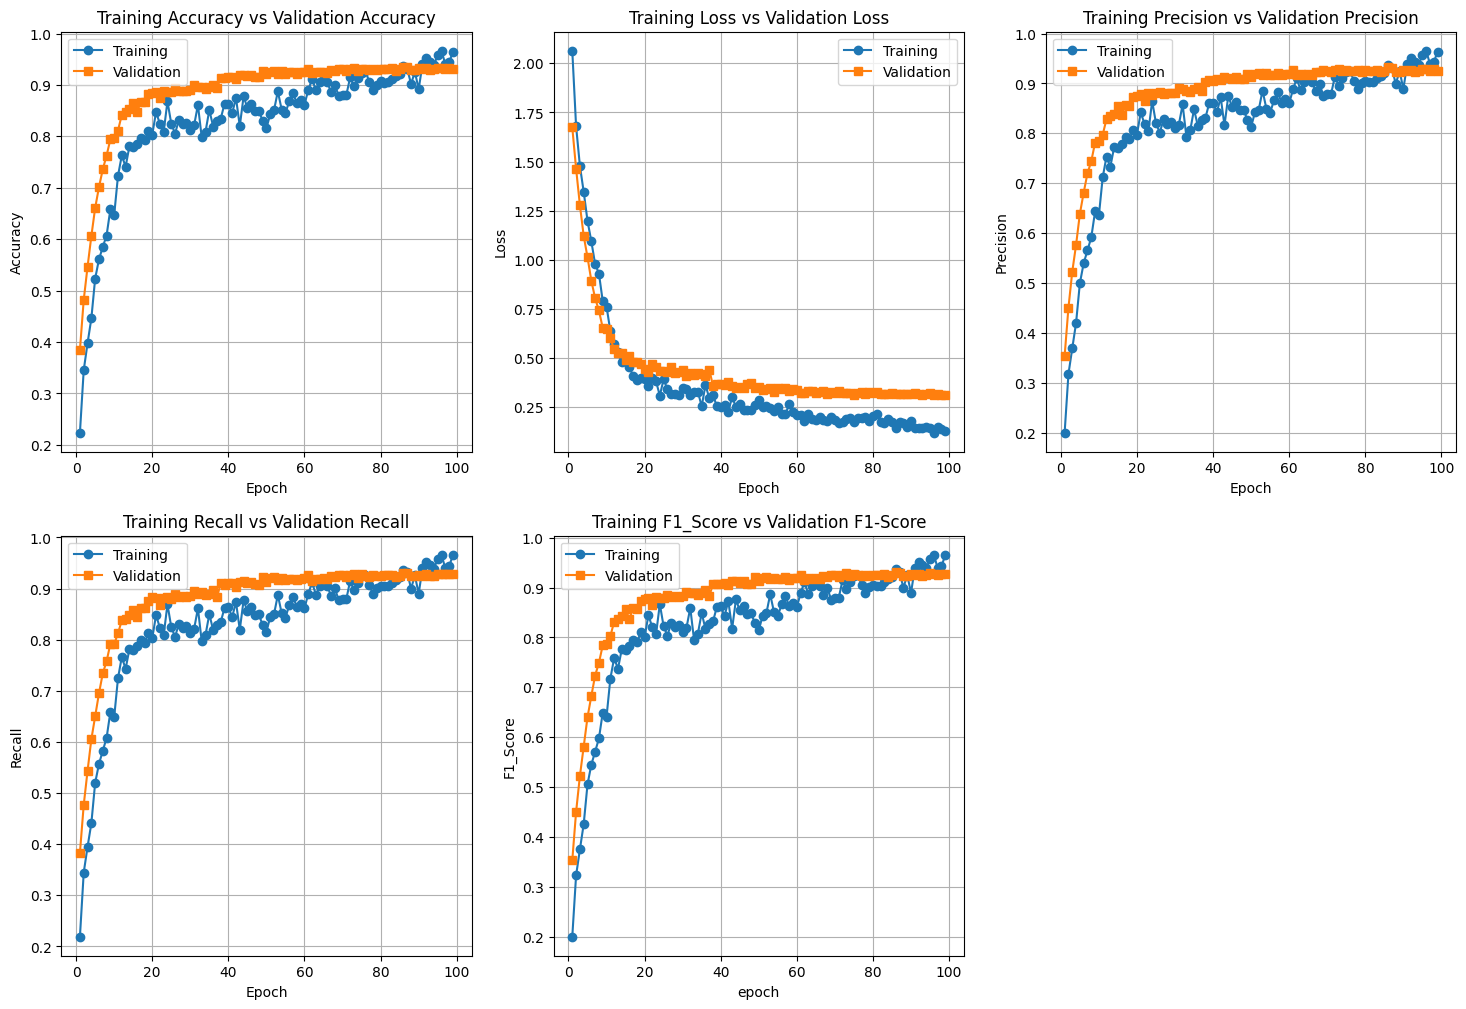

In [ ]:
plt.figure(figsize=(18, 12))

# Build x-axes based on actual recorded lengths
train_epochs = list(range(1, len(train_loss) + 1))
val_epochs   = list(range(1, len(val_loss) + 1))



utility.plot_line_graph(train_epochs = train_epochs, train_records = train_accuracy, train_label = "Training",
                        val_epochs = val_epochs, val_records = val_accuracy, val_label = "Validation", title = "Training Accuracy vs Validation Accuracy",
                        xlabel = "Epoch", ylabel = "Accuracy", shape = (2, 3, 1))

utility.plot_line_graph(train_epochs = train_epochs, train_records = train_loss, train_label = "Training",
                        val_epochs = val_epochs, val_records = val_loss, val_label = "Validation", title = "Training Loss vs Validation Loss",
                        xlabel = "Epoch", ylabel = "Loss", shape = (2, 3, 2))

utility.plot_line_graph(train_epochs = train_epochs, train_records = train_precision, train_label = "Training",
                        val_epochs = val_epochs, val_records = val_precision, val_label = "Validation", title = "Training Precision vs Validation Precision",
                        xlabel = "Epoch", ylabel = "Precision", shape = (2, 3, 3))

utility.plot_line_graph(train_epochs = train_epochs, train_records = train_recall, train_label = "Training",
                        val_epochs = val_epochs, val_records = val_recall, val_label = "Validation", title = "Training Recall vs Validation Recall",
                        xlabel = "Epoch", ylabel = "Recall", shape = (2, 3, 4))

utility.plot_line_graph(train_epochs = train_epochs, train_records = train_f1score, train_label = "Training",
                        val_epochs = val_epochs, val_records = val_f1score, val_label = "Validation", title = "Training F1_Score vs Validation F1-Score",
                        xlabel = "epoch", ylabel = "F1_Score", shape = (2, 3, 5))

## Training Set Confusion Matrix (Last Epoch)

Visualize model performance on training set using confusion matrix.

**Interpretation**:
- Diagonal elements: Correctly classified samples
- Off-diagonal elements: Misclassifications
- Row i, Column j: True class=i, Predicted class=j

**Analysis**:
- Identify which genre pairs are often confused
- Check if model is memorizing training data (near-perfect matrix suggests overfitting)


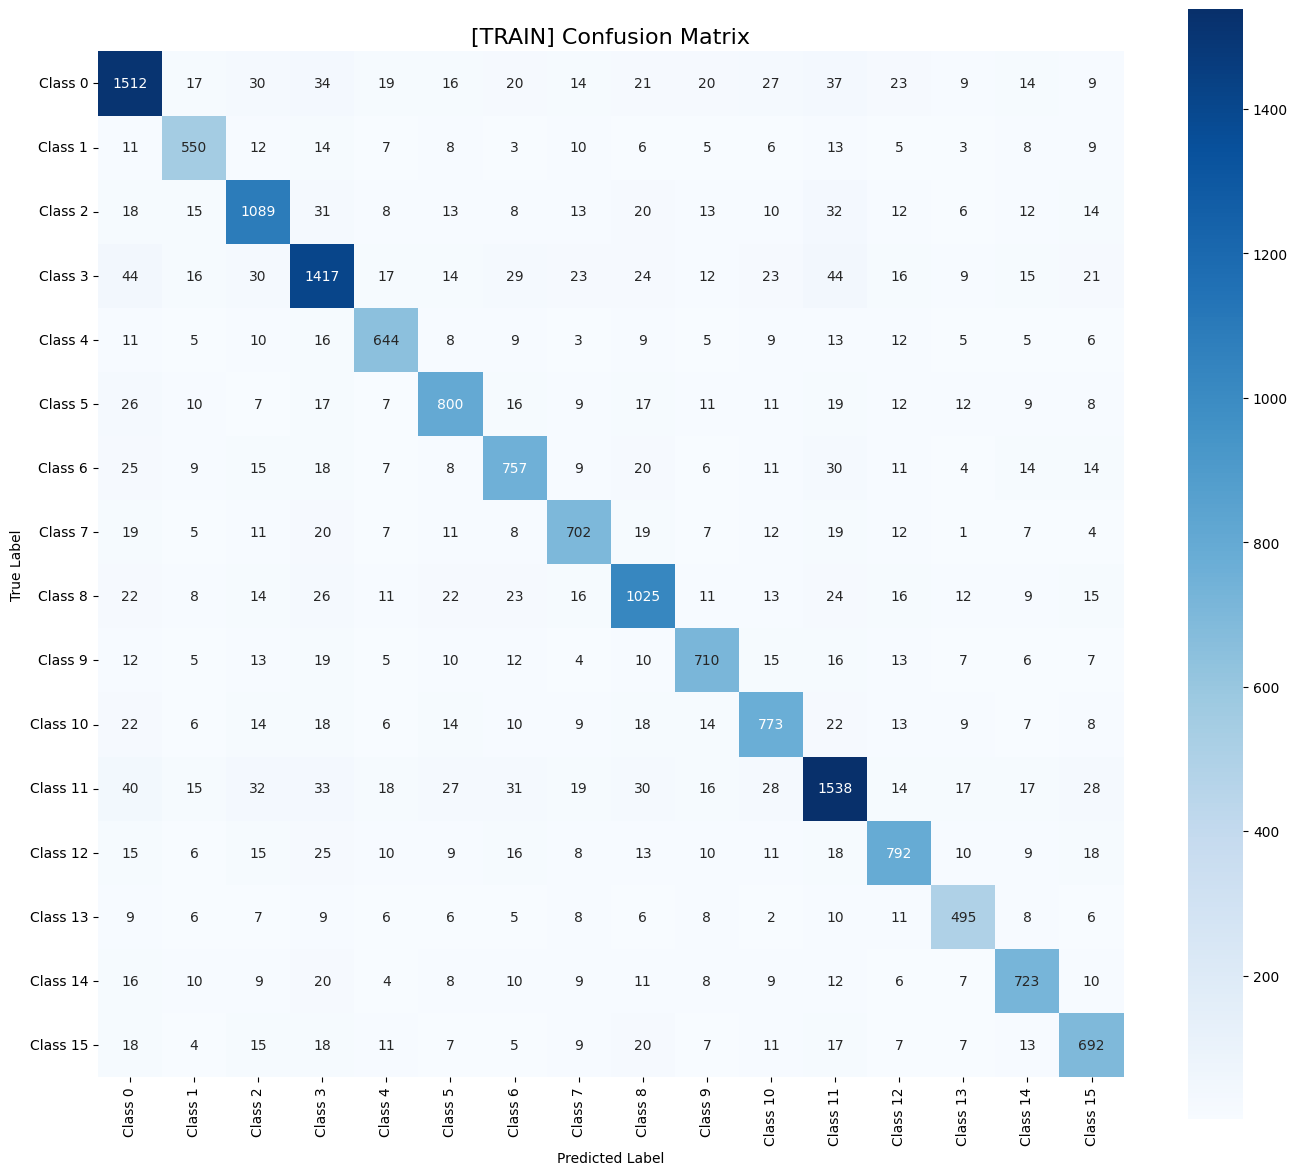

In [ ]:

tmat = train_obs["confusion_matrix"]
classes = [f"Class {i}" for i in range(len(tmat))]
utility.plot_confusion_matrix(tmat, classes, title="[TRAIN] Confusion Matrix")

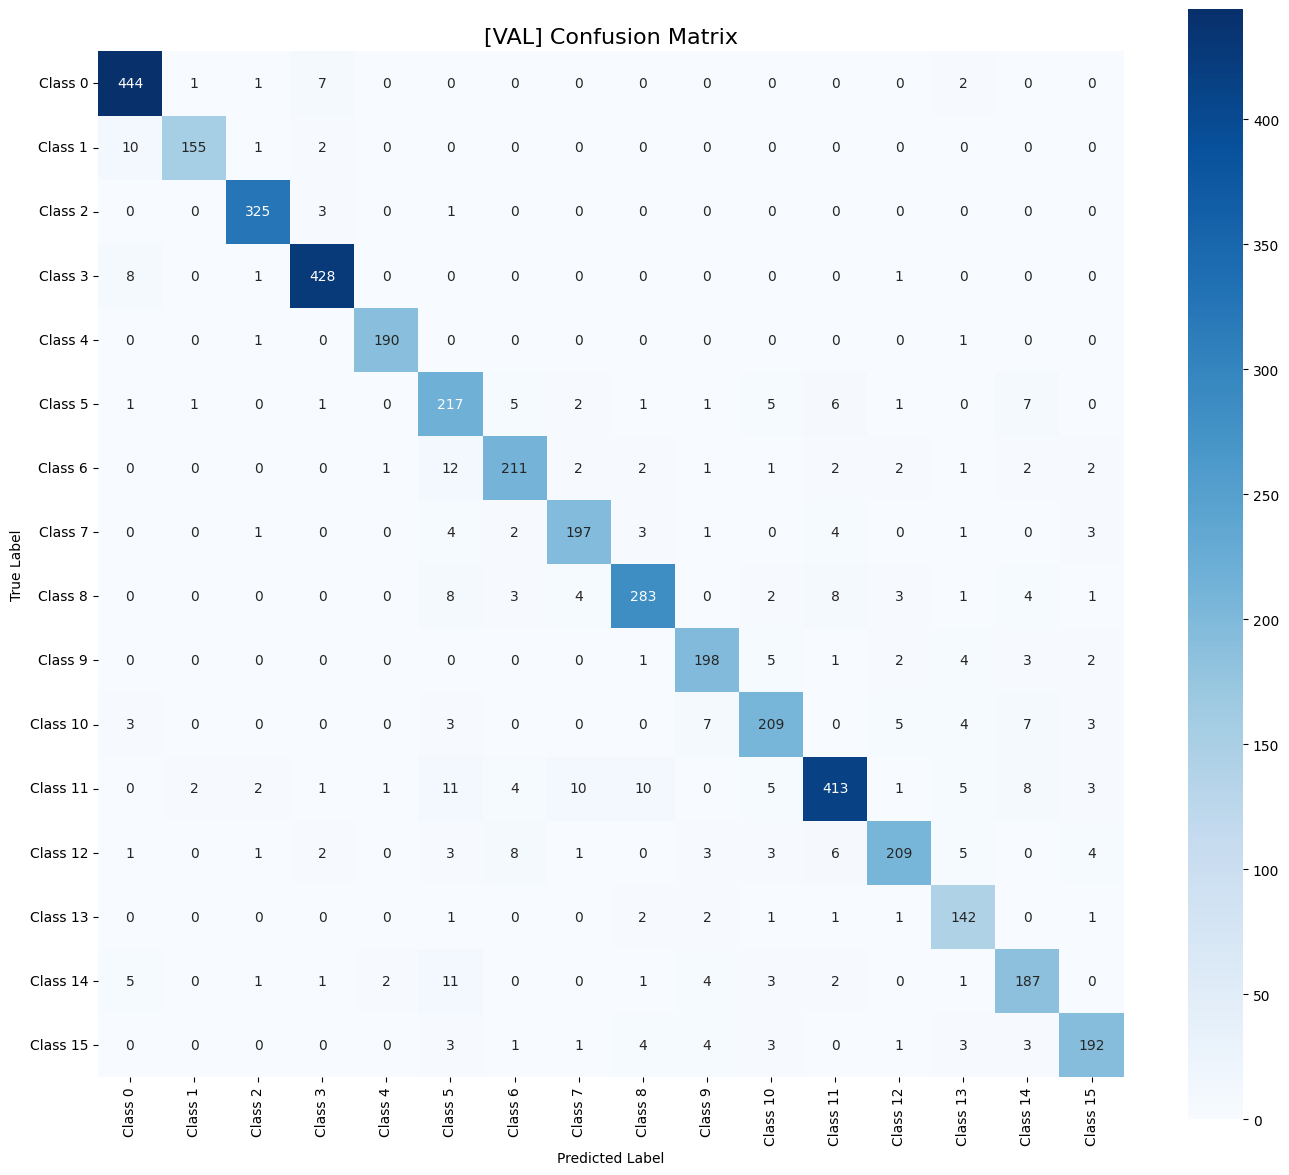

In [ ]:

vmat = val_obs["confusion_matrix"]
utility.plot_confusion_matrix(vmat, classes, title="[VAL] Confusion Matrix")

# Testing

# Loading Test Data

In [ ]:
test_meta_df = pd.read_csv(os.path.join(base_path, test_path, "metadata.csv"))
print(f"metadata shape: {test_meta_df.shape}")
test_meta_df.head(10)

metadata shape: (14550, 4)


,id,input_1_path,input_2,input_3
0,0,./dataset_music/test/input_1/000000.jpg,./dataset_music/test/input_2/000000.jpg,./dataset_music/test/input_3/000000.jpg
1,1,./dataset_music/test/input_1/000001.jpg,./dataset_music/test/input_2/000001.jpg,./dataset_music/test/input_3/000001.jpg
2,2,./dataset_music/test/input_1/000002.jpg,./dataset_music/test/input_2/000002.jpg,./dataset_music/test/input_3/000002.jpg
3,3,./dataset_music/test/input_1/000003.jpg,./dataset_music/test/input_2/000003.jpg,./dataset_music/test/input_3/000003.jpg
4,4,./dataset_music/test/input_1/000004.jpg,./dataset_music/test/input_2/000004.jpg,./dataset_music/test/input_3/000004.jpg
5,5,./dataset_music/test/input_1/000005.jpg,./dataset_music/test/input_2/000005.jpg,./dataset_music/test/input_3/000005.jpg
6,6,./dataset_music/test/input_1/000006.jpg,./dataset_music/test/input_2/000006.jpg,./dataset_music/test/input_3/000006.jpg
7,7,./dataset_music/test/input_1/000007.jpg,./dataset_music/test/input_2/000007.jpg,./dataset_music/test/input_3/000007.jpg
8,8,./dataset_music/test/input_1/000008.jpg,./dataset_music/test/input_2/000008.jpg,./dataset_music/test/input_3/000008.jpg
9,9,./dataset_music/test/input_1/000009.jpg,./dataset_music/test/input_2/000009.jpg,./dataset_music/test/input_3/000009.jpg


In [ ]:
test_meta_df.isnull().sum()

id              0
input_1_path    0
input_2         0
input_3         0
dtype: int64

In [ ]:
test_dataset = CustomDataset(test_meta_df, base_path, transform = transform, train = False)
test_loader = DataLoader(test_dataset, batch_size, num_workers=4, shuffle=False)

In [ ]:
print("Dataset size:", len(test_dataset))

x, y = test_dataset[0]
print("Input shape:", x.shape)
print("Label:", y)

Dataset size: 14550
Input shape: torch.Size([3, 3, 96, 96])
Label: 0


# Load Best Model

In [ ]:
import os
import torch

def load_best_checkpoint(model, ckpt_path, device, strict=True):
    ckpt = torch.load(ckpt_path, map_location=device)

    # load weights
    model.load_state_dict(ckpt["model_state_dict"], strict=strict)
    model.to(device)
    model.eval()

    print(
        f"[LOAD] Loaded best checkpoint from: {ckpt_path} | "
        f"epoch={ckpt.get('epoch')} | best_val_f1={ckpt.get('best_val_f1'):.4f} | best_val_loss={ckpt.get('best_val_loss'):.4f}"
    )
    return ckpt


In [ ]:
best_path = os.path.join(store_path, "best_checkpoint.pt")
ckpt = load_best_checkpoint(model, best_path, device)

[LOAD] Loaded best checkpoint from: /kaggle/working/model_weights/best_checkpoint.pt | epoch=86 | best_val_f1=0.9315 | best_val_loss=0.3197


In [ ]:
results = []

with torch.no_grad():
    for data, iids in tqdm(test_loader, desc="Testing"):
        data = data.to(device, non_blocking=True)

        logits = model(data)
        pred_labels = logits.argmax(dim=1)
        iids = iids.cpu().tolist()
        pred_labels = pred_labels.cpu().tolist()

        results.extend(zip(iids, pred_labels))


Testing: 100%|██████████| 228/228 [02:45<00:00,  1.38it/s]


In [ ]:


result_df = pd.DataFrame(results, columns=["id", "predicted_label"])

test_result_path = "/kaggle/working/submission.csv"
result_df.to_csv(test_result_path, index=False)

print("Saved submission.csv!")


Saved submission.csv!


# Models Tried Summary

---

## 1. Multi-View CNN with Mid-Level Fusion (≈0.41M parameters)

**Architecture**

Input `<B, 3 views, 1×64×64>`  
→ Per-view Feature Extraction: Conv(1→24) → Conv(24→24, stride 2) → Conv(24→48, stride 2)  
→ Feature size per view: `<48, 16×16>`  
→ Mid Fusion: Concatenate 3 views (144 channels) → 1×1 Conv (144→96)  
→ Deep Feature Learning: Conv(96→144, stride 2) → Conv(144→192, stride 2)  
→ Global Avg Pool → FC (192 → num_classes) → Output  

**Performance**  
- Accuracy: **47.38%**  
- F1-score: **0.466**

**Notes**  
Used mid-level fusion to combine complementary multi-view information while keeping the model lightweight (~407K params).

---

## 2. Multi-View CNN with Pairwise Interaction Fusion (≈0.47M parameters)

**Architecture**

Input `<B, 3 views, 1×48×48>`  
→ Per-view Feature Extraction: Conv(1→32) → Conv(32→64) → MaxPool → Conv(64→128) → MaxPool → Conv(128→192)  
→ Feature size per view: `<192, 12×12>`  
→ Global Avg Pool → Pairwise Interaction (non-learnable) → `<64>`  
→ FC: 192→384 → 384→192 → 192→num_classes → Output  

**Performance**  
- Accuracy: **88.19%**  
- F1-score: **0.882**

**Notes**  
Pairwise interaction explicitly models cross-view relationships, improving performance over simple fusion while remaining lightweight (~465K params).

---

## 3. Multi-View CNN with Residual & Dense Fusion (≈0.48M params)

**Key Changes**
- Early residual connection for stable optimization  
- Dense skip (feature concatenation) before classifier  
- Retained pairwise interaction  

**Performance**  
- Accuracy: **89.22%**  
- F1: **0.892**  
- Recall: **0.892**  
- Precision: **0.894**

**Notes**  
Improved feature reuse and optimization over Model 2.

---

## 4. Residual Multi-View CNN + Music Augmentation

**Key Changes**
- Pitch shift (vertical roll)  
- SpecAugment (time & frequency masking)  

**Performance**  
- Accuracy: **87.31%**  
- F1: **0.874**  
- Recall: **0.874**  
- Precision: **0.875**

**Notes**  
Improved robustness but introduced harder samples, slightly reducing performance.

---

## 5. Residual Multi-View CNN + Mixup, Weighted Loss & Normalization (≈0.48M params)

**Key Changes**
- Mixup augmentation  
- Label smoothing (0.01)  
- Class-weighted cross-entropy  
- Input normalization (mean=0.5, std=0.25)  
- BatchNorm + Tanh after fusion  
- BatchNorm in FC head  

**Performance**  
- Accuracy: **87.81%**  
- F1: **0.878**  
- Recall: **0.878**  
- Precision: **0.878**

**Notes**  
Improved class balance and training stability.

---

## 6. Residual Multi-Stage CNN with Learnable Pairwise Fusion (≈0.37M params)

**Architecture**

Input `<B, 3 views, 1×64×64>`  
→ Residual Blocks with progressive downsampling (32→64→96→128)  
→ Global Avg Pool → Learnable Pairwise Fusion → Dense Skip Fusion  
→ FC Head: BatchNorm → ReLU → Dropout → FC → Concat Skip → BatchNorm → ReLU → Dropout → FC → Output  

**Performance**  
- Accuracy: **90.65%**  
- F1-score: **0.901**

**Notes**  
Multi-stage residual learning + learnable pairwise fusion with **two BatchNorm layers** improved feature stability and cross-view representation while keeping parameters low (~0.37M).

---

## 7. Residual Multi-Stage CNN (Single BatchNorm Variant)

**Key Change**
- Removed first BatchNorm from FC head  

**Performance**  
- Accuracy: **91.73%**  
- F1: **0.912**  
- Recall: **0.912**  
- Precision: **0.913**

**Notes**  
Reduced over-regularization and improved optimization, giving the best overall performance.

---
## 8. Final Optimized Multi-View RGB Model (Scheduled Mixup + Regularized Pairwise Fusion)

**Key Motivation**  
Initial models treated inputs as grayscale, but the dataset was RGB. After correcting to **in_channels=3**, performance plateaued around **0.89–0.90 macro-F1** with noticeable class confusions and unstable late training when MixUp → 0 (fast memorization/overfitting).


**Targeted Improvements**

**Data & Training Strategy**
- Corrected **RGB input handling**
- **Scheduled MixUp**: stronger early, weaker later  
- Late **fine-tuning phase** with weaker augmentation + smaller LR  
- Resolution tuning and improved augmentation for regularization  
- EMA for smoother validation performance  

**Architecture**
- Added **skip connections** for stable optimization  
- Clean **multi-view design**: shared lightweight encoder per view → fused embeddings → classifier  
- Used **pairwise interaction fusion** (regularized to avoid overfitting)  
- Tuned FC head (Dropout **0.25 → 0.20**) and considered custom **BatchNorm1D**

**Macro-F1 Focused Improvements**
- Optional **class-weighted loss**
- **WeightedRandomSampler** for class balance  
- Considered **Focal Loss** for hard/minority classes  
- Compared **Cosine LR vs ReduceLROnPlateau** (cosine smoother, plateau reactive)  
- Saved and evaluated **best checkpoint by macro-F1**  

**Final Performance**
- Validation **Macro-F1: 0.934**
